In [7]:
import pandas as pd
import numpy as np

df = pd.read_csv("/Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/data/raw_data.csv")
print(df.shape)
df.head()



(100, 24)


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [8]:
rename_map = {
    "SKU": "sku_id",
    "Product type": "category",
    "Number of products sold": "units_sold",
    "Stock levels": "inventory_on_hand",
    "Lead times": "lead_time_days",
    "Order quantities": "order_qty",
    "Shipping times": "shipping_time_days",
    "Shipping costs": "shipping_cost",
    "Supplier name": "supplier_name",
    "Location": "warehouse",
    "Defect rates": "defect_rate",
    "Inspection results": "inspection_result"
}
df = df.rename(columns=rename_map)
df.columns.tolist()

['category',
 'sku_id',
 'Price',
 'Availability',
 'units_sold',
 'Revenue generated',
 'Customer demographics',
 'inventory_on_hand',
 'lead_time_days',
 'order_qty',
 'shipping_time_days',
 'Shipping carriers',
 'shipping_cost',
 'supplier_name',
 'warehouse',
 'Lead time',
 'Production volumes',
 'Manufacturing lead time',
 'Manufacturing costs',
 'inspection_result',
 'defect_rate',
 'Transportation modes',
 'Routes',
 'Costs']

In [9]:
import duckdb

# Recreate the flag just in case
df["delayed_shipment_flag"] = (df["shipping_time_days"] > df["lead_time_days"]).astype(int)

con = duckdb.connect()
con.register("supply_chain", df)

result = con.execute("""
SELECT
    supplier_name,
    COUNT(*) AS total_orders,
    SUM(delayed_shipment_flag) AS delayed_orders,
    ROUND(100.0 * SUM(delayed_shipment_flag) / COUNT(*), 2) AS delay_pct
FROM supply_chain
GROUP BY supplier_name
ORDER BY delay_pct DESC
""").fetchdf()

print(result)

  supplier_name  total_orders  delayed_orders  delay_pct
0    Supplier 5            18             5.0      27.78
1    Supplier 3            15             4.0      26.67
2    Supplier 2            22             3.0      13.64
3    Supplier 4            18             2.0      11.11
4    Supplier 1            27             3.0      11.11


In [10]:
# Recreate the flag
df["low_inventory_flag"] = (df["inventory_on_hand"] <= df["order_qty"]).astype(int)

# Re-register the updated df
con.register("supply_chain", df)

result2 = con.execute("""
SELECT
    warehouse,
    COUNT(*) AS total_records,
    SUM(low_inventory_flag) AS low_inventory_records,
    ROUND(100.0 * SUM(low_inventory_flag) / COUNT(*), 2) AS risk_pct
FROM supply_chain
GROUP BY warehouse
ORDER BY risk_pct DESC
""").fetchdf()

print(result2)

   warehouse  total_records  low_inventory_records  risk_pct
0    Chennai             20                   15.0     75.00
1     Mumbai             22                   13.0     59.09
2      Delhi             15                    8.0     53.33
3    Kolkata             25                   11.0     44.00
4  Bangalore             18                    7.0     38.89


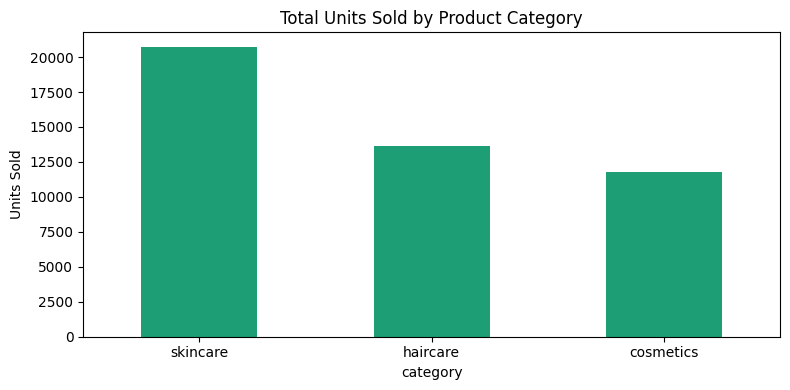

In [11]:
import matplotlib.pyplot as plt

# Units sold by category
cat_demand = df.groupby("category")["units_sold"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,4))
cat_demand.plot(kind="bar", color="#1D9E75")
plt.title("Total Units Sold by Product Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/dashboard/dashboard_screenshots/demand_by_category.png", dpi=150)
plt.show()

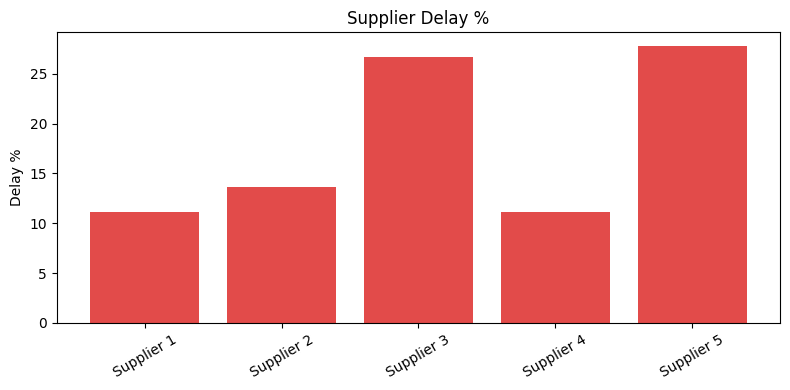

In [12]:
# Supplier delay chart
supplier_delay = (
    df.groupby("supplier_name")
      .agg(total=("sku_id","count"), delayed=("delayed_shipment_flag","sum"))
      .reset_index()
)
supplier_delay["delay_pct"] = (supplier_delay["delayed"] / supplier_delay["total"] * 100).round(2)

plt.figure(figsize=(8,4))
plt.bar(supplier_delay["supplier_name"], supplier_delay["delay_pct"], color="#E24B4A")
plt.title("Supplier Delay %")
plt.ylabel("Delay %")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("/Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/dashboard/dashboard_screenshots/supplier_delay.png", dpi=150)
plt.show()


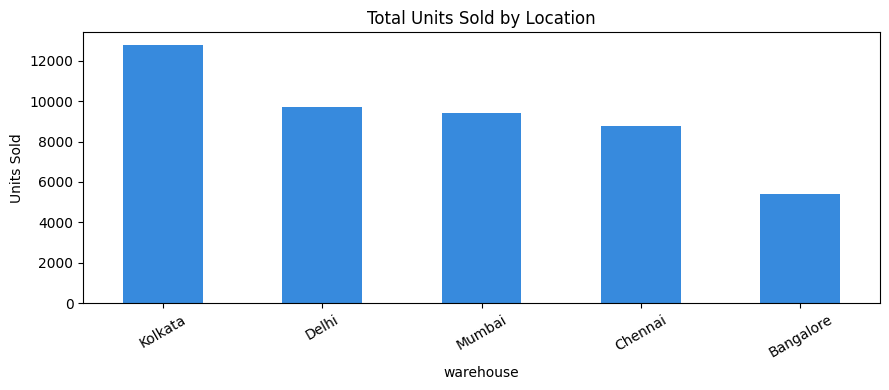

In [13]:
# Warehouse inventory risk chart
loc_demand = df.groupby("warehouse")["units_sold"].sum().sort_values(ascending=False)

plt.figure(figsize=(9,4))
loc_demand.plot(kind="bar", color="#378ADD")
plt.title("Total Units Sold by Location")
plt.ylabel("Units Sold")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("/Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/dashboard/dashboard_screenshots/demand_by_location.png", dpi=150)
plt.show()

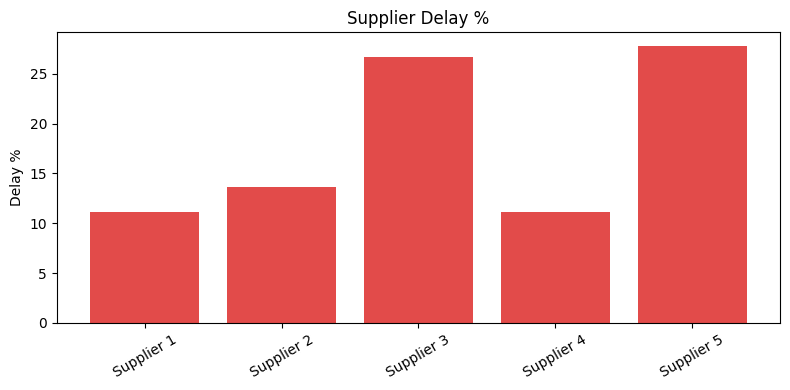

In [14]:
# Supplier delay chart
supplier_delay = (
    df.groupby("supplier_name")
      .agg(total=("sku_id","count"), delayed=("delayed_shipment_flag","sum"))
      .reset_index()
)
supplier_delay["delay_pct"] = (supplier_delay["delayed"] / supplier_delay["total"] * 100).round(2)

plt.figure(figsize=(8,4))
plt.bar(supplier_delay["supplier_name"], supplier_delay["delay_pct"], color="#E24B4A")
plt.title("Supplier Delay %")
plt.ylabel("Delay %")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("/Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/dashboard/dashboard_screenshots/supplier_delay.png", dpi=150)
plt.show()

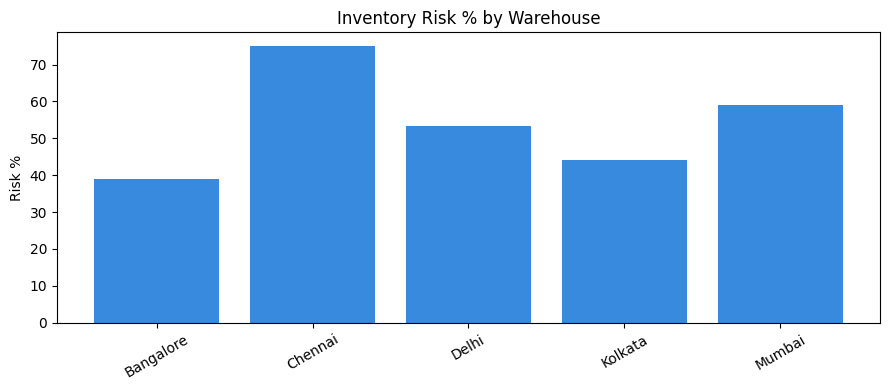

In [15]:
# Warehouse inventory risk chart
warehouse_risk = (
    df.groupby("warehouse")["low_inventory_flag"]
      .agg(["sum", "count"])
      .reset_index()
)
warehouse_risk["risk_pct"] = (warehouse_risk["sum"] / warehouse_risk["count"] * 100).round(2)

plt.figure(figsize=(9,4))
plt.bar(warehouse_risk["warehouse"], warehouse_risk["risk_pct"], color="#378ADD")
plt.title("Inventory Risk % by Warehouse")
plt.ylabel("Risk %")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("/Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/dashboard/dashboard_screenshots/warehouse_risk.png", dpi=150)
plt.show()

In [16]:
df.to_csv("/Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/data/cleaned_data.csv", index=False)
print("✅ saved! Rows:", len(df))


✅ saved! Rows: 100


In [17]:
import pandas as pd

df_check = pd.read_csv("/Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/data/cleaned_data.csv")
print("Rows:", len(df_check))
print("Columns:", df_check.columns.tolist())
df_check.head()

Rows: 100
Columns: ['category', 'sku_id', 'Price', 'Availability', 'units_sold', 'Revenue generated', 'Customer demographics', 'inventory_on_hand', 'lead_time_days', 'order_qty', 'shipping_time_days', 'Shipping carriers', 'shipping_cost', 'supplier_name', 'warehouse', 'Lead time', 'Production volumes', 'Manufacturing lead time', 'Manufacturing costs', 'inspection_result', 'defect_rate', 'Transportation modes', 'Routes', 'Costs', 'delayed_shipment_flag', 'low_inventory_flag']


,category,sku_id,Price,Availability,units_sold,Revenue generated,Customer demographics,inventory_on_hand,lead_time_days,order_qty,...,Production volumes,Manufacturing lead time,Manufacturing costs,inspection_result,defect_rate,Transportation modes,Routes,Costs,delayed_shipment_flag,low_inventory_flag
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075,0,1
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579,0,0
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282,0,1
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159,0,1
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632,1,1


In [18]:
import pandas as pd
import numpy as np

# Read raw file again
df = pd.read_csv("/Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/data/raw_data.csv")

# Rename columns
rename_map = {
    "SKU": "sku_id",
    "Product type": "category",
    "Number of products sold": "units_sold",
    "Stock levels": "inventory_on_hand",
    "Lead times": "lead_time_days",
    "Order quantities": "order_qty",
    "Shipping times": "shipping_time_days",
    "Shipping costs": "shipping_cost",
    "Supplier name": "supplier_name",
    "Location": "warehouse",
    "Defect rates": "defect_rate",
    "Inspection results": "inspection_result"
}
df = df.rename(columns=rename_map)
df["delayed_shipment_flag"] = (df["shipping_time_days"] > df["lead_time_days"]).astype(int)
df["low_inventory_flag"] = (df["inventory_on_hand"] <= df["order_qty"]).astype(int)
df["inventory_gap"] = df["inventory_on_hand"] - df["order_qty"]

# Save properly
df.to_csv("/Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/data/cleaned_data.csv", index=False)
print("✅ Rows saved:", len(df))

✅ Rows saved: 100


In [19]:
verify = pd.read_csv("/Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/data/cleaned_data.csv")
print("✅ Rows in file:", len(verify))
print("✅ File size check passed!" if len(verify) > 0 else "❌ Still empty!")


✅ Rows in file: 100
✅ File size check passed!


In [20]:
ls -lh "/Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/data/cleaned_data.csv"

-rw-r--r--@ 1 hemanth.nagesh07gmail.com  staff    21K Apr 28 12:53 /Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/data/cleaned_data.csv


In [21]:
import pandas as pd

df = pd.read_csv("/Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/data/cleaned_data.csv")

# Save with explicit encoding
df.to_csv("/Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/data/cleaned_data_upload.csv", 
          index=False, 
          encoding='utf-8-sig')

print("✅ Saved! Rows:", len(df))

✅ Saved! Rows: 100


In [22]:
ls -lh ~/Downloads/cleaned_data_final.csv

ls: /Users/hemanth.nagesh07gmail.com/Downloads/cleaned_data_final.csv: No such file or directory


In [23]:
import pandas as pd
import numpy as np

raw_path = "/Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/data/raw_data.csv"

df = pd.read_csv(raw_path)
print(df.shape)
df.head()

(100, 24)


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [24]:
df.columns.tolist()

['Product type',
 'SKU',
 'Price',
 'Availability',
 'Number of products sold',
 'Revenue generated',
 'Customer demographics',
 'Stock levels',
 'Lead times',
 'Order quantities',
 'Shipping times',
 'Shipping carriers',
 'Shipping costs',
 'Supplier name',
 'Location',
 'Lead time',
 'Production volumes',
 'Manufacturing lead time',
 'Manufacturing costs',
 'Inspection results',
 'Defect rates',
 'Transportation modes',
 'Routes',
 'Costs']

In [25]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("-", "_")
)

df.columns.tolist()

['product_type',
 'sku',
 'price',
 'availability',
 'number_of_products_sold',
 'revenue_generated',
 'customer_demographics',
 'stock_levels',
 'lead_times',
 'order_quantities',
 'shipping_times',
 'shipping_carriers',
 'shipping_costs',
 'supplier_name',
 'location',
 'lead_time',
 'production_volumes',
 'manufacturing_lead_time',
 'manufacturing_costs',
 'inspection_results',
 'defect_rates',
 'transportation_modes',
 'routes',
 'costs']

In [26]:
cleaned_path = "/Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/data/cleaned_data.csv"

df.to_csv(cleaned_path, index=False)

print("Cleaned file saved successfully")
print(df.shape)

Cleaned file saved successfully
(100, 24)


In [27]:
test = pd.read_csv(cleaned_path)
print(test.shape)
test.head()

(100, 24)


,product_type,sku,price,availability,number_of_products_sold,revenue_generated,customer_demographics,stock_levels,lead_times,order_quantities,...,location,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,inspection_results,defect_rates,transportation_modes,routes,costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [28]:
df.columns.tolist()

['product_type',
 'sku',
 'price',
 'availability',
 'number_of_products_sold',
 'revenue_generated',
 'customer_demographics',
 'stock_levels',
 'lead_times',
 'order_quantities',
 'shipping_times',
 'shipping_carriers',
 'shipping_costs',
 'supplier_name',
 'location',
 'lead_time',
 'production_volumes',
 'manufacturing_lead_time',
 'manufacturing_costs',
 'inspection_results',
 'defect_rates',
 'transportation_modes',
 'routes',
 'costs']

In [29]:
cleaned_path = "/Users/hemanth.nagesh07gmail.com/Desktop/supply-chain-analytics/data/cleaned_data.csv"

test = pd.read_csv(cleaned_path)
print(test.shape)
test.head()

(100, 24)


,product_type,sku,price,availability,number_of_products_sold,revenue_generated,customer_demographics,stock_levels,lead_times,order_quantities,...,location,lead_time,production_volumes,manufacturing_lead_time,manufacturing_costs,inspection_results,defect_rates,transportation_modes,routes,costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [30]:
test.columns.tolist()

['product_type',
 'sku',
 'price',
 'availability',
 'number_of_products_sold',
 'revenue_generated',
 'customer_demographics',
 'stock_levels',
 'lead_times',
 'order_quantities',
 'shipping_times',
 'shipping_carriers',
 'shipping_costs',
 'supplier_name',
 'location',
 'lead_time',
 'production_volumes',
 'manufacturing_lead_time',
 'manufacturing_costs',
 'inspection_results',
 'defect_rates',
 'transportation_modes',
 'routes',
 'costs']